In [1]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from torchvision.datasets import MNIST
import numpy as np
from typing import Tuple
from PIL import Image
import mammoth


/home/lorenzo_24_04/anaconda3/envs/mammoth_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from datasets import get_dataset_class
class Args:
    dataset = 'perm-lat-mnist'
    # aggiungi altri parametri necessari (n_t, batch_size, etc.)
    n_t = 100
    joint=0
    custom_task_order=0
    custom_class_order=0
    permute_classes=0
    label_perc=0
    seed=0
    validation=0
    noise_rate=0
dataset_class = get_dataset_class(Args)


In [3]:
dataset_class

datasets.perm_lat_mnist.PermutedLatMNIST

In [4]:
print("Inizializzazione PermutedLatMNIST...")
T_steps = 20 # Step temporali della sRNN
dataset = dataset_class(Args)
train_loaders, _ = dataset.get_data_loaders()

for task_id, loader in enumerate(train_loaders):
    print(f"\n--- TASK {task_id + 1} ---")
    
    # Prendiamo solo il primo batch per ogni task come esempio
    for i, (inputs, targets, original_imgs) in enumerate(loader):
        print(f"Batch {i+1}:")
        print(f"  Input (Latency) shape: {inputs.shape}  -> [Batch, T, Features]")
        print(f"  Targets shape: {targets.shape}")
        print(f"  Spikes totali nel batch: {inputs.sum().item()}")
        
        # Verifica che il latency encoding funzioni:
        # Gli spike dovrebbero essere distribuiti lungo T
        spikes_per_t = inputs.sum(dim=(0, 2))
        print(f"  Distribuzione spike nei primi 5 step: {spikes_per_t[:5].tolist()}")
        
        break # Passiamo alla prossima task


Inizializzazione PermutedLatMNIST...


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (10,) + inhomogeneous part.

In [ ]:
import torch
all_data=torch.load('sim_output_33000.pt')


In [22]:
all_data['w_rec'].shape
print(f"w_rec between: {all_data['w_rec'].min()} and {all_data['w_rec'].max()}, with mean: {all_data['w_rec'].mean()} and std: {all_data['w_rec'].std()}")
print(f"w_rec has {torch.count_nonzero(all_data['w_rec']>0)} positive values, {torch.count_nonzero(all_data['w_rec']<0)} negative values, {all_data['w_rec'].numel()} total values")

w_rec between: -0.21110564470291138 and 0.3018791675567627, with mean: 0.0038049770519137383 and std: 0.021747944876551628
w_rec has 12716 positive values, 9634 negative values, 22500 total values


In [29]:
all_data['w_rec'][0,:]
for i in range(150):
    print(f"w_rec has {torch.count_nonzero(all_data['w_rec'][i,:]>0)} positive values, {torch.count_nonzero(all_data['w_rec'][i,:]<0)} negative values, {all_data['w_rec'][0,:].numel()} total values")


w_rec has 77 positive values, 72 negative values, 150 total values
w_rec has 103 positive values, 46 negative values, 150 total values
w_rec has 69 positive values, 80 negative values, 150 total values
w_rec has 116 positive values, 33 negative values, 150 total values
w_rec has 103 positive values, 46 negative values, 150 total values
w_rec has 93 positive values, 56 negative values, 150 total values
w_rec has 52 positive values, 97 negative values, 150 total values
w_rec has 87 positive values, 62 negative values, 150 total values
w_rec has 88 positive values, 61 negative values, 150 total values
w_rec has 83 positive values, 66 negative values, 150 total values
w_rec has 98 positive values, 51 negative values, 150 total values
w_rec has 60 positive values, 89 negative values, 150 total values
w_rec has 82 positive values, 67 negative values, 150 total values
w_rec has 86 positive values, 63 negative values, 150 total values
w_rec has 91 positive values, 58 negative values, 150 total

In [ ]:
[94.64,86.41, 88.16,75.6,71.75,75.76,79.59,74.73,71.56,75.4 ]
[94.64]
[79.36507936507937, 93.45238095238095]
[79.16666666666666, 90.47619047619048, 94.84126984126983]
[58.730158730158735, 66.86507936507937, 82.73809523809523, 94.04761904761905]
[45.43650793650794, 66.07142857142857, 70.83333333333334, 82.14285714285714, 94.24603174603175]
[53.37301587301587, 58.730158730158735, 79.96031746031747, 80.75396825396825, 87.6984126984127, 94.04761904761905]
[58.53174603174603, 68.25396825396825, 79.16666666666666, 83.33333333333334, 87.6984126984127, 85.71428571428571, 94.44444444444444]
[63.29365079365079, 51.388888888888886, 67.65873015873017, 72.02380952380952, 84.32539682539682, 78.96825396825396, 87.3015873015873, 92.85714285714286]
[56.94444444444444, 62.301587301587304, 66.46825396825396, 70.03968253968253, 67.46031746031747, 76.5873015873016, 75.39682539682539, 75.1984126984127, 93.65079365079364]
[63.29365079365079, 58.730158730158735, 61.30952380952381, 71.82539682539682, 77.77777777777779, 83.53174603174604, 75.1984126984127, 80.35714285714286, 87.6984126984127, 94.24603174603175]

In [ ]:
[92.86,88.89,84.79,90.95,79.37,76.92,73.33,75.84,65.12]
[92.85714285714286]
[85.31746031746032, 92.46031746031747]
[75.39682539682539, 86.5079365079365, 92.46031746031747]
[66.46825396825396, 76.19047619047619, 88.69047619047619, 92.46031746031747]
[62.89682539682539, 68.65079365079364, 85.31746031746032, 87.6984126984127, 92.26190476190477]
[55.158730158730165, 65.07936507936508, 80.15873015873017, 84.72222222222221, 85.9126984126984, 90.47619047619048]
[52.77777777777778, 63.888888888888886, 67.85714285714286, 72.22222222222221, 80.75396825396825, 83.53174603174604, 92.26190476190477]
[57.341269841269835, 62.89682539682539, 76.19047619047619, 74.0079365079365, 76.5873015873016, 79.56349206349206, 88.09523809523809, 92.06349206349206]
[32.53968253968254, 49.60317460317461, 48.41269841269841, 54.96031746031746, 63.49206349206349, 78.57142857142857, 78.96825396825396, 86.5079365079365, 93.05555555555556]
[49.007936507936506, 57.53968253968254, 63.49206349206349, 53.37301587301587, 77.57936507936508, 78.76984126984127, 79.96031746031747, 85.51587301587301, 88.09523809523809, 91.46825396825396]

In [2]:
import torch

data=torch.load('debug_data/stats_task_0.pt')

In [ ]:
data['fisher']['w_in']

torch.Size([150, 1196])

In [17]:
import re

file_path = 'srnn_ewc2.log'
file_path= 'output_ewc_20tasks.log'
results = []

# Pattern: Matches "Raw Accuracy", then any spaces, then captures everything inside []
pattern = re.compile(r'Domain-IL \s*\[(.*?)\]')

with open(file_path, 'r') as file:
    for line in file:
        match = pattern.search(line)
        if match:
            # Extract the string inside brackets and split by comma or space
            values_str = match.group(1)
            # Converts the string values into a list of floats
            values = [float(v.strip()) for v in values_str.replace(',', ' ').split()]
            results.append(values)

print(results)

[[92.06349206349206], [92.06349206349206], [78.17460317460318, 90.47619047619048], [78.17460317460318, 90.47619047619048], [81.15079365079364, 85.31746031746032, 92.26190476190477], [81.15079365079364, 85.31746031746032, 92.26190476190477], [79.76190476190477, 83.53174603174604, 86.70634920634922, 87.3015873015873], [79.76190476190477, 83.53174603174604, 86.70634920634922, 87.3015873015873], [59.32539682539682, 78.17460317460318, 81.74603174603175, 79.16666666666666, 92.06349206349206], [59.32539682539682, 78.17460317460318, 81.74603174603175, 79.16666666666666, 92.06349206349206], [67.85714285714286, 75.59523809523809, 65.87301587301587, 75.59523809523809, 89.28571428571429, 90.27777777777779], [67.85714285714286, 75.59523809523809, 65.87301587301587, 75.59523809523809, 89.28571428571429, 90.27777777777779], [66.46825396825396, 80.95238095238095, 69.24603174603175, 75.0, 83.33333333333334, 85.71428571428571, 93.25396825396825], [66.46825396825396, 80.95238095238095, 69.24603174603175,

In [18]:
for r in results[::2]:
    print(r)

[92.06349206349206]
[78.17460317460318, 90.47619047619048]
[81.15079365079364, 85.31746031746032, 92.26190476190477]
[79.76190476190477, 83.53174603174604, 86.70634920634922, 87.3015873015873]
[59.32539682539682, 78.17460317460318, 81.74603174603175, 79.16666666666666, 92.06349206349206]
[67.85714285714286, 75.59523809523809, 65.87301587301587, 75.59523809523809, 89.28571428571429, 90.27777777777779]
[66.46825396825396, 80.95238095238095, 69.24603174603175, 75.0, 83.33333333333334, 85.71428571428571, 93.25396825396825]
[60.11904761904761, 74.40476190476191, 73.61111111111111, 78.96825396825396, 84.72222222222221, 85.11904761904762, 89.28571428571429, 93.65079365079364]
[51.587301587301596, 73.80952380952381, 64.68253968253968, 66.26984126984127, 75.79365079365078, 81.34920634920636, 85.9126984126984, 85.9126984126984, 89.88095238095238]
[56.74603174603175, 73.01587301587301, 56.15079365079365, 66.07142857142857, 71.23015873015873, 82.14285714285714, 83.33333333333334, 87.10317460317461

In [15]:
!pip install snakeviz

In [ ]:
import re


file_path= 'metapl_493387.log'

ch_grad = []
avg_mod = []


pattern_ch = re.compile(r'coherent grads=\s*([\d.]+)%')
pattern_mod = re.compile(r'Avg Modulation=\s*([\d.]+)')


with open(file_path, 'r') as file:
    for line in file:
        # Cerca Coherent Grads
        match_ch = pattern_ch.search(line)
        if match_ch:
            ch_grad.append(float(match_ch.group(1)))

        

        # Cerca Avg Modulation
        match_mod = pattern_mod.search(line)
        if match_mod:
            avg_mod.append(float(match_mod.group(1)))

print(f"Coherent Grads (%): {ch_grad}")
print(f"Avg Modulation: {avg_mod}")

Coherent Grads (%): [49.5, 48.7, 50.8, 48.2, 44.3, 47.2, 45.7, 34.9, 42.5, 43.0, 29.7, 39.3, 40.7, 24.9, 33.4, 39.9, 21.6, 30.7, 39.0, 19.3, 30.1, 37.0, 16.1, 26.5, 35.6, 15.2, 27.5, 34.6, 13.1, 25.5, 33.4, 12.7, 23.6, 33.5, 13.1, 21.9, 32.4, 11.4, 20.8, 32.0, 12.3, 23.7, 31.2, 10.6, 21.5, 30.9, 9.8, 18.5, 29.9, 9.5, 19.3, 29.9, 9.9, 19.9, 30.0, 9.5, 19.3, 29.7, 9.8, 19.3, 30.0, 10.0, 20.9, 29.7, 9.4, 18.7, 29.4, 9.5, 17.2, 29.3, 9.9, 20.3, 29.6, 9.6, 19.3, 29.2, 9.7, 19.9, 29.4, 9.9, 20.3, 28.1, 9.8, 19.3, 28.3, 9.7, 19.5, 28.5, 9.2, 18.7, 29.1, 9.8, 19.7, 29.0, 9.7, 18.1, 28.5, 10.0, 22.2, 29.1, 9.8, 19.7, 28.7, 9.6, 19.5, 27.6, 9.9, 17.7, 28.4, 9.6, 20.1, 28.5, 10.1, 20.3, 28.5, 10.0, 20.3, 28.3, 9.9, 21.5, 29.2, 10.9, 21.9, 29.0, 10.0, 19.3, 28.4, 9.4, 19.7, 28.4, 10.3, 20.3, 28.6, 10.1, 20.6, 28.6, 9.6, 20.0, 28.9, 9.9, 19.9, 27.8, 9.8, 19.7, 28.4, 9.5, 19.3, 28.4, 9.5, 19.3, 28.5, 10.1, 19.6, 28.9, 10.4, 20.3, 28.1, 10.1, 19.7, 28.2, 10.0, 19.0, 28.5, 9.1, 18.3, 28.8, 10.1, 17.3,

In [24]:
len(avg_mod)

84600

In [1]:
import torch
import os

folder_name='debug_data_metapl_2/'
data=[ torch.load(folder_name+f) for f in os.listdir(folder_name)]
n_tasks=len(data)
print(f'found {n_tasks} file, each with keys: {data[0].keys()}')

found 7 file, each with keys: dict_keys(['task_id', 'weights', 'firing_rates', 'labels', 'losses', 'outputs'])


In [2]:
for i in range(n_tasks):
    n_datapoints=len(data[i]['losses'])
    print(f" file {i} has {n_datapoints} datapoints with keys {data[i]['losses'][0].keys()}")

 file 0 has 47 datapoints with keys dict_keys(['main_grad', 'metapl_reduction'])
 file 1 has 47 datapoints with keys dict_keys(['main_grad', 'metapl_reduction'])
 file 2 has 47 datapoints with keys dict_keys(['main_grad', 'metapl_reduction'])
 file 3 has 47 datapoints with keys dict_keys(['main_grad', 'metapl_reduction'])
 file 4 has 47 datapoints with keys dict_keys(['main_grad', 'metapl_reduction'])
 file 5 has 47 datapoints with keys dict_keys(['main_grad', 'metapl_reduction'])
 file 6 has 47 datapoints with keys dict_keys(['main_grad', 'metapl_reduction'])


In [63]:
datapoint=0
data[task_id]['losses'][datapoint]['main_grad']['g_in'].norm()


tensor(279.8016)

In [50]:
task_id=1
red_in=[data[task_id]['losses'][j]['metapl_reduction']['g_in'] for j in range(n_datapoints)]
red_rec=[data[task_id]['losses'][j]['metapl_reduction']['g_rec'] for j in range(n_datapoints)]
red_out=[data[task_id]['losses'][j]['metapl_reduction']['g_out'] for j in range(n_datapoints)]

In [53]:
print(red_rec)

[0.3035663664340973, 3.3825016021728516, 3.180687665939331, 1.5493427515029907, 0.28358349204063416, 2.718860387802124, 6.824044704437256, 11.790111541748047, 8.012847900390625, 5.73288631439209, 5.390784740447998, 5.160096168518066, 6.915864944458008, 5.112114429473877, 5.5412821769714355, 5.071421146392822, 6.58148193359375, 7.163690090179443, 4.894213676452637, 11.102416038513184, 4.4539995193481445, 6.631106853485107, 4.311877250671387, 4.762784004211426, 22.66118621826172, 25.579898834228516, 6.947544574737549, 9.000288963317871, 4.3616862297058105, 18.21608543395996, 6.400347709655762, 4.775473594665527, 7.801799297332764, 17.763031005859375, 186.60397338867188, 13.642091751098633, 4.815447807312012, 3.7727131843566895, 4.537573337554932, 18.413097381591797, 6.580704689025879, 60.85517883300781, 19.893590927124023, 67.72813415527344, 106.0804214477539, 42.13990020751953, 106.50617218017578]


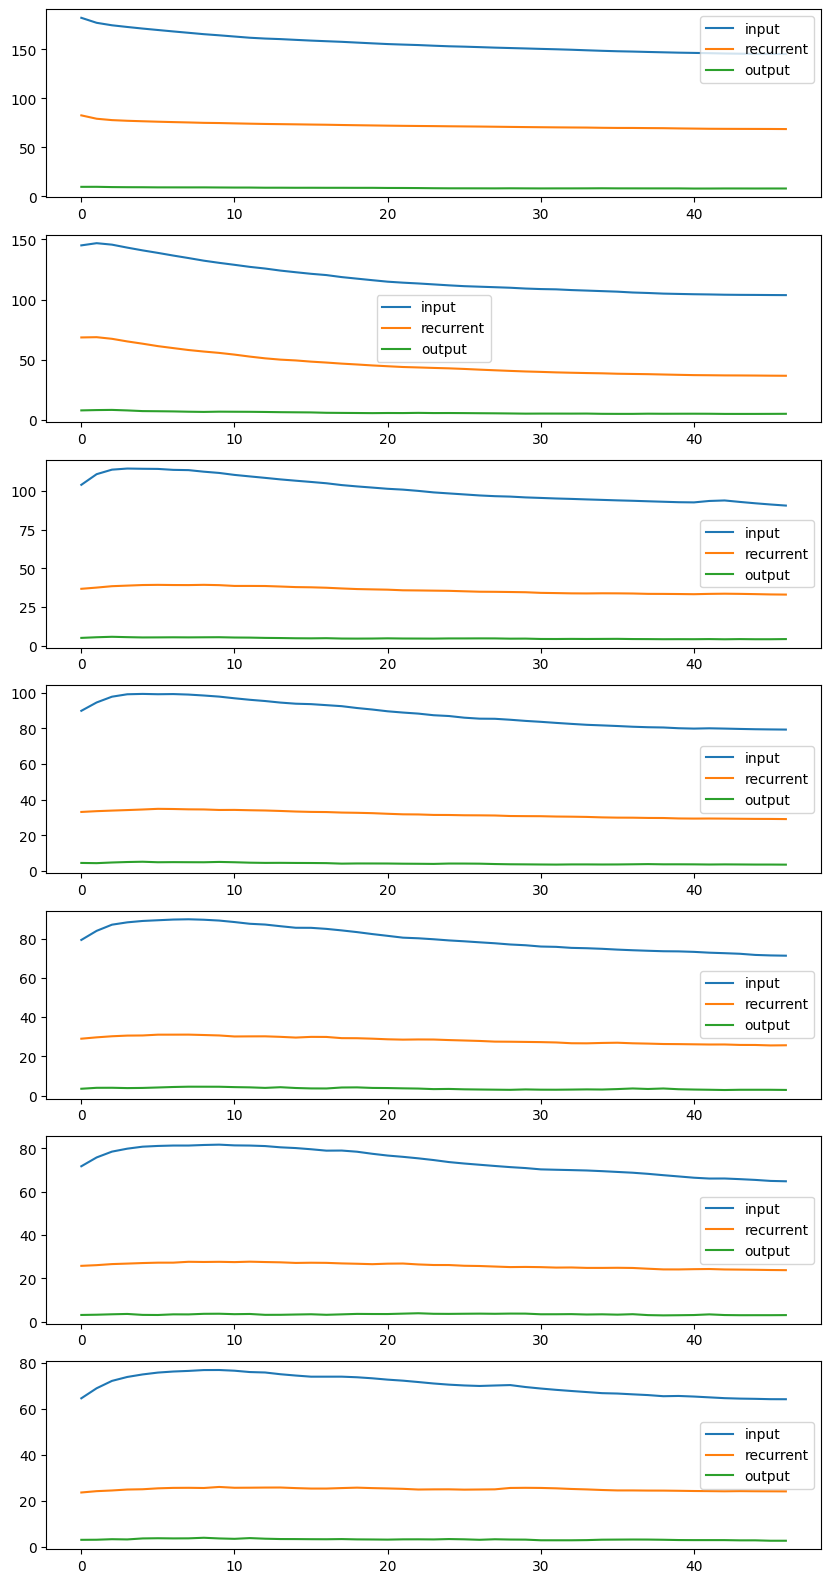

In [66]:
import matplotlib.pyplot as plt
fig,axs=plt.subplots(n_tasks,figsize=(10,20))
for i in range(n_tasks):
    
    g_in_norms=[data[i]['losses'][j]['main_grad']['g_in'].norm() for j in range(n_datapoints)]
    g_rec_norms=[data[i]['losses'][j]['main_grad']['g_rec'].norm() for j in range(n_datapoints)]
    g_out_norms=[data[i]['losses'][j]['main_grad']['g_out'].norm() for j in range(n_datapoints)]
    red_in_norm=[data[i]['losses'][j]['metapl_reduction']['g_in'] for j in range(n_datapoints)]
    red_rec_norm=[data[i]['losses'][j]['metapl_reduction']['g_rec'] for j in range(n_datapoints)]
    red_out_norm=[data[i]['losses'][j]['metapl_reduction']['g_out'] for j in range(n_datapoints)]

    red_in=[a*b for a,b in zip(g_in_norms,red_in_norm)]
    red_rec=[a*b for a,b in zip(g_rec_norms,red_rec_norm)]
    red_out=[a*b for a,b in zip(g_out_norms,red_out_norm)]
    
    axs[i].plot(red_in,label='input')
    axs[i].plot(red_rec,label='recurrent')
    axs[i].plot(red_out,label='output')
    axs[i].legend()

27.324242
13.630331
960.9798
19.16161
9.704943
719.40045
16.560963
7.8366246
658.66693
15.681324
9.4018135
669.5775
11.388227
5.9629445
521.4006
14.954105
8.482577
731.1846
13.813761
7.2411876
636.47925


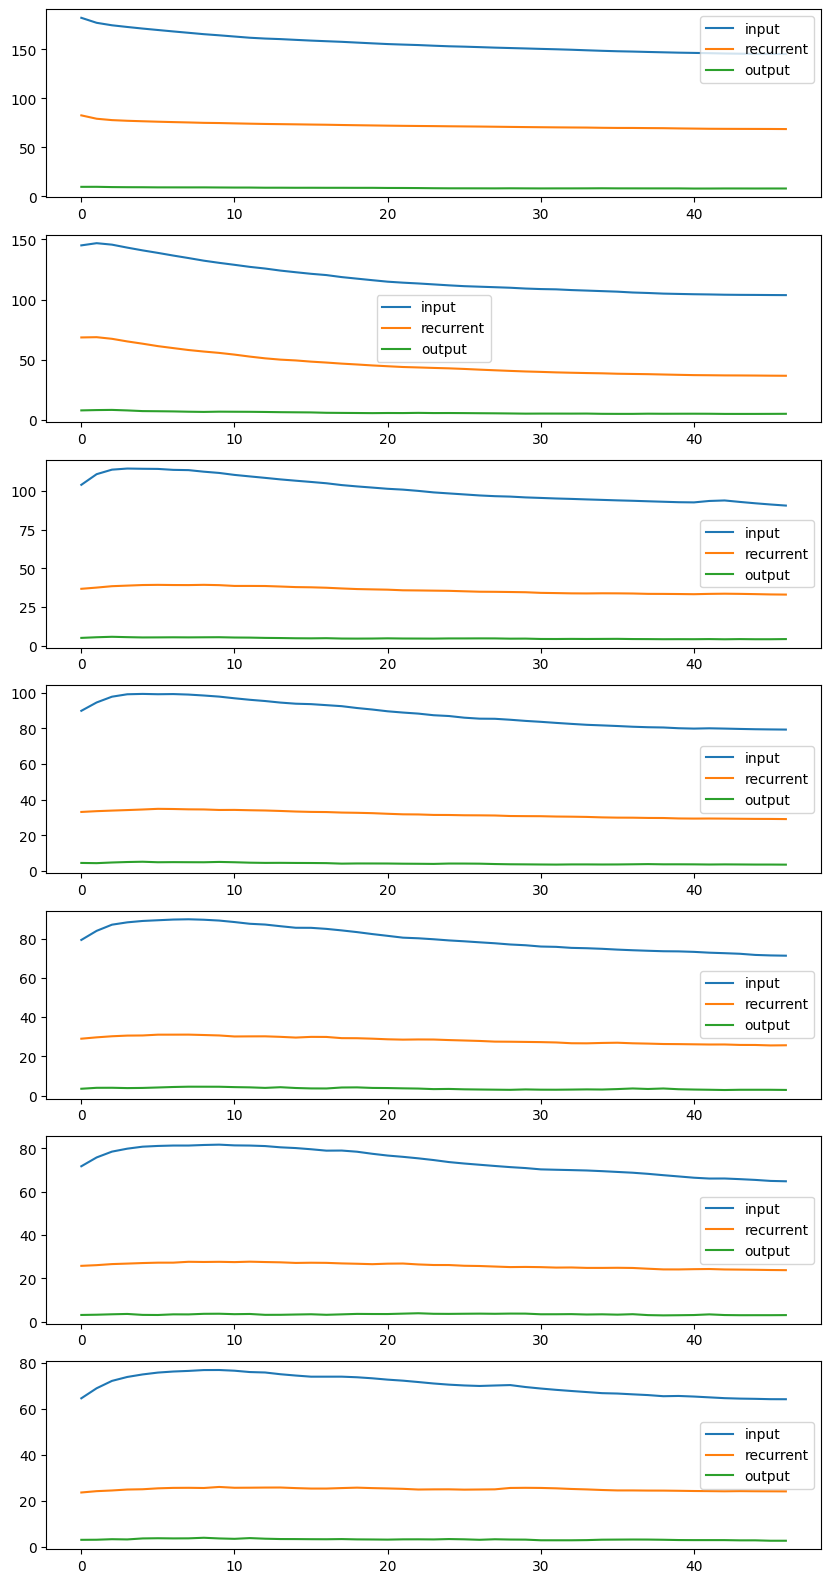

In [72]:
import numpy as np
fig,axs=plt.subplots(n_tasks,figsize=(10,20))
for i in range(n_tasks):
    
    g_in_norms=[data[i]['losses'][j]['main_grad']['g_in'].norm() for j in range(n_datapoints)]
    g_rec_norms=[data[i]['losses'][j]['main_grad']['g_rec'].norm() for j in range(n_datapoints)]
    g_out_norms=[data[i]['losses'][j]['main_grad']['g_out'].norm() for j in range(n_datapoints)]
    print(np.mean(g_in_norms))
    print(np.mean(g_rec_norms))
    print(np.mean(g_out_norms))
    red_in_norm=[data[i]['losses'][j]['metapl_reduction']['g_in'] for j in range(n_datapoints)]
    red_rec_norm=[data[i]['losses'][j]['metapl_reduction']['g_rec'] for j in range(n_datapoints)]
    red_out_norm=[data[i]['losses'][j]['metapl_reduction']['g_out'] for j in range(n_datapoints)]

    red_in=[a*b for a,b in zip(g_in_norms,red_in_norm)]
    red_rec=[a*b for a,b in zip(g_rec_norms,red_rec_norm)]
    red_out=[a*b for a,b in zip(g_out_norms,red_out_norm)]
    
    axs[i].plot(red_in,label='input')
    axs[i].plot(red_rec,label='recurrent')
    axs[i].plot(red_out,label='output')
    axs[i].legend()

In [10]:
import matplotlib.pyplot as plt
xi=100
for i in range(n_tasks):
    print(f"task {i}")
    print(f"w_in between {data[i]['weights']['w_in'].min()} and {data[i]['weights']['w_in'].max()}")
    print(f"w_re between {data[i]['weights']['w_rec'].min()} and {data[i]['weights']['w_rec'].max()}")
    print(f"w_out between {data[i]['weights']['w_out'].min()} and {data[i]['weights']['w_out'].max()}")
    tmp_in = torch.exp(-xi * torch.abs(data[i]['weights']['w_in']))
    tmp_rec = torch.exp(-xi * torch.abs(data[i]['weights']['w_rec']))
    tmp_out = torch.exp(-xi * torch.abs(data[i]['weights']['w_out']))
    # print(tmp_in.shape)
    # print(tmp_rec.shape)
    # print(tmp_out.shape)
    # plt.figure()
    # plt.hist(tmp_in,label='in')
    # plt.hist(tmp_rec,label='rec')
    # plt.hist(tmp_out,label='out')
    # plt.legend()
    # plt.show()

task 0
w_in between -0.10467266291379929 and 0.11467640846967697
w_re between -0.08967579156160355 and 0.08745307475328445
w_out between -0.21421736478805542 and 0.18681108951568604
task 1
w_in between -0.13372297585010529 and 0.1206754818558693
w_re between -0.1089414656162262 and 0.12627820670604706
w_out between -0.22868070006370544 and 0.19505733251571655
task 2
w_in between -0.1468815952539444 and 0.12629540264606476
w_re between -0.13059581816196442 and 0.1435444951057434
w_out between -0.2330506592988968 and 0.21010372042655945
task 3
w_in between -0.1490478366613388 and 0.14731904864311218
w_re between -0.14783068001270294 and 0.15138760209083557
w_out between -0.23135609924793243 and 0.20988185703754425
task 4
w_in between -0.1530497670173645 and 0.14570021629333496
w_re between -0.1563148945569992 and 0.1534174382686615
w_out between -0.2321382611989975 and 0.21800358593463898
task 5
w_in between -0.15758545696735382 and 0.15061020851135254
w_re between -0.16132467985153198 a